In [1]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


data = pd.read_csv('./dataset/diamonds.csv')
print(data.head())

# 범주형 데이터 -> Label Encoding
label_encoders = {}
for column in ['cut', 'color', 'clarity']:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le

# 피처와 타겟 데이터 분리
X = data.drop(['price'], axis=1)
y = data['price']

# 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
    )

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R2 Score: {r2}')


   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
Mean Squared Error: 453.6714025769372
R2 Score: 0.9999714615022904


c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54924 (\N{HANGUL SYLLABLE HOE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44480 (\N{HANGUL SYLLABLE GWI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.p

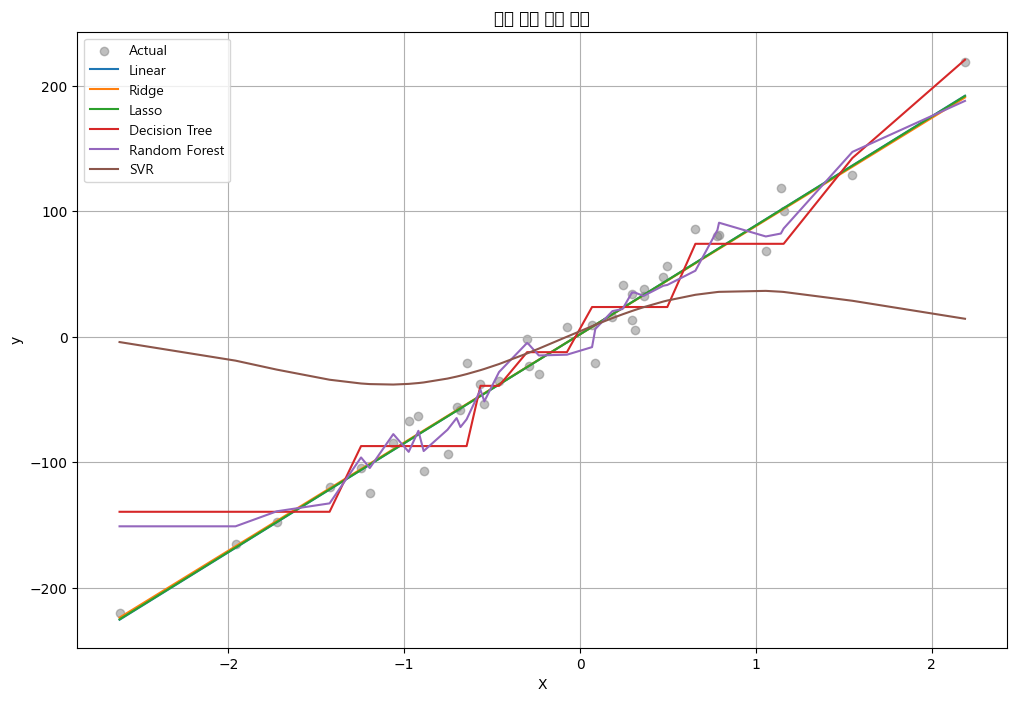

           Model          MSE        R2
0         Linear   246.121793  0.968085
2          Lasso   246.499305  0.968036
1          Ridge   248.485451  0.967779
4  Random Forest   440.887637  0.942830
3  Decision Tree   653.587642  0.915249
5            SVR  4789.737580  0.378915


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso


from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# 1. 간단한 회귀용 데이터 생성
X, y = make_regression(n_samples=200, n_features=1, noise=15, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. 사용할 회귀 모델들 정의
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=3),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "SVR": SVR()
}

# 3. 학습 및 예측 결과 저장
results = []

plt.figure(figsize=(12, 8))
plt.scatter(X_test, y_test, color='gray', alpha=0.5, label="Actual")

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })
    
    # 예측선 시각화
    sorted_idx = np.argsort(X_test[:, 0])
    plt.plot(X_test[sorted_idx], y_pred[sorted_idx], label=name)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.title("회귀 모델 예측 비교")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# 4. 모델 성능 비교 출력
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(df_results)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso


from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("./dataset/winequality-red.csv")

print("데이터 크기:", df.shape)
print(df.head())


X = df.drop("quality", axis=1)
y = df["quality"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 전체 데이터의 20%를 테스트용으로 사용
    random_state=42     # 결과를 항상 같게 만들기
)


# 2. 사용할 회귀 모델들 정의
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=3),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    "SVR": SVR()
}

# 3. 학습 및 예측 결과 저장
results = []


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })
    

print('_'*50)

# 4. 모델 성능 비교 출력
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(df_results)


데이터 크기: (1599, 12)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, r2_score


df = pd.read_csv("./dataset/diamonds.csv")

print("원본 데이터 크기:", df.shape)
print(df.head())


# price 상위 1% 제거
price_limit = df["price"].quantile(0.99)
df = df[df["price"] < price_limit]

# carat 상위 1% 제거
carat_limit = df["carat"].quantile(0.99)
df = df[df["carat"] < carat_limit]

print("이상치 제거 후 데이터 크기:", df.shape)


# 범주형 컬럼 숫자로 변환
# cut, color, clarity는 문자이므로 숫자로 변환
df = pd.get_dummies(df, columns=["cut", "color", "clarity"])


# 5. 특성(X) / 타깃(y) 분리
X = df.drop("price", axis=1)
y = df["price"]


# 학습용 / 테스트용 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# 2. 사용할 회귀 모델들 정의
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1),
    "Decision Tree": DecisionTreeRegressor(max_depth=3),
    "Random Forest": RandomForestRegressor(n_estimators=100),
    #"SVR": SVR()
}

# 3. 학습 및 예측 결과 저장
results = []


for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        'Model': name,
        'MSE': mse,
        'R2': r2
    })
    

print('_'*50)

# 4. 모델 성능 비교 출력
df_results = pd.DataFrame(results).sort_values(by='R2', ascending=False)
print(df_results)


원본 데이터 크기: (53940, 11)
   Unnamed: 0  carat      cut color clarity  depth  table  price     x     y  \
0           1   0.23    Ideal     E     SI2   61.5   55.0    326  3.95  3.98   
1           2   0.21  Premium     E     SI1   59.8   61.0    326  3.89  3.84   
2           3   0.23     Good     E     VS1   56.9   65.0    327  4.05  4.07   
3           4   0.29  Premium     I     VS2   62.4   58.0    334  4.20  4.23   
4           5   0.31     Good     J     SI2   63.3   58.0    335  4.34  4.35   

      z  
0  2.43  
1  2.31  
2  2.31  
3  2.63  
4  2.75  
이상치 제거 후 데이터 크기: (52861, 11)


c:\SK_Shieldus_Rookies\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.214e+08, tolerance: 5.508e+07
  model = cd_fast.enet_coordinate_descent(


__________________________________________________
           Model           MSE        R2
4  Random Forest  6.908787e+02  0.999946
3  Decision Tree  5.955853e+05  0.953333
2          Lasso  1.003110e+06  0.921401
1          Ridge  1.003269e+06  0.921389
0         Linear  1.003394e+06  0.921379
